# RL-6 : Deep Q-Network (DQN) et Policy Gradient

**Serie** : Reinforcement Learning | **Notebook** : 6/13 | **Duree estimee** : 50-55 min

Navigation : [RL-1 Intro](rl_1_intro_cartpole.ipynb) | [RL-2 Wrappers](rl_2_wrappers_sauvegarde_callbacks.ipynb) | [RL-3 HER](rl_3_experience_replay_dqn.ipynb) | [RL-5 Tabulaire](rl_5_mdp_dp_qlearning.ipynb) | **RL-6** | [RL-7 Multi-Agent](rl_7_multi_agent_rl.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
- Implementer un DQN complet depuis zero avec replay buffer et target network
- Comprendre les defis de l'apprentissage hors-ligne (stabilite, correlation)
- Implementer REINFORCE, l'algorithme de base du Policy Gradient
- Comparer les approches value-based et policy-based

## Prerequis

- [RL-5 MDP/Q-Learning tabulaire](rl_5_mdp_dp_qlearning.ipynb) (concepts Q-value, TD learning)
- Bases de PyTorch (tenseurs, autograd, Module)
- [RL-1 Introduction](rl_1_intro_cartpole.ipynb) (environnement CartPole)

---

**Pourquoi des reseaux de neurones ?**
- Le Q-Learning tabulaire stocke $Q(s,a)$ pour chaque paire état-action. Impossible avec des espaces continus.
- Un reseau de neurones approche $Q(s,a; \theta)$ avec des paramètres $\theta$, generalisant aux etats jamais vus.
- Le DQN (DeepMind, 2013/2015) a ete le premier algorithme a demontrer l'apprentissage RL a l'echelle avec des reseaux profonds.

## 1. Installation et imports

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt

# Reproductibilite (C864-L) : le notebook etait stochastique (aucun seed),
# ce qui faisait deriver les recompenses a chaque re-exec (DQN 128->500->472 sur
# 3 runs). On fixe un seed canonique pour rendre les resultats reproductibles.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"gymnasium={gym.__version__}, numpy={np.__version__}")
print(f"torch={torch.__version__}")

gymnasium=1.3.0, numpy=2.4.3
torch=2.8.0+cu126


Nous travaillons sur CartPole-v1, un environnement avec un espace d'observation continu (4 dimensions) et un espace d'action discret (2 actions). C'est un environnement ideal pour DQN car il est assez simple pour converger rapidement mais necessite déjà une approximation par reseau de neurones.

**CartPole-v1 en resume** : Un chariot avec un baton equilibre. Observation = [position, vitesse, angle, vitesse_angulaire]. Actions = [gauche, droite]. Recompense = +1 par pas, episode termine si le baton tombe ou le chariot sort de l'ecran.

## 2. Architecture du DQN

Le DQN introduit deux innovations cles par rapport au Q-Learning tabulaire :

1. **Expérience Replay** : Stockage des transitions dans un buffer et echantillonnage aleatoire pour casser les correlations temporelles
2. **Target Network** : Un second reseau cible stabilise l'apprentissage en fournissant des cibles moins volatiles

Le reseau de neurones prend en entree l'observation (4 valeurs) et produit en sortie les Q-valeurs pour chaque action (2 valeurs).


> *Ancres savantes -- Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015), Human-level control through deep reinforcement learning, Nature 518:529-533, DOI 10.1038/nature14236 (DQN, combine approximation neuronale de Q avec expérience replay et target network, premier RL humain-niveau sur Atari brut) ; Lin, L.-J. (1992), Self-Improving Reactive Agents Based on Reinforcement Learning, Planning and Teaching, Machine Learning 8:293-321 (expérience replay, casse les correlations temporelles entre transitions) ; Williams, R.J. (1992), Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning, Neural Computation 4(3):405-414 (REINFORCE, gradient de politique Monte Carlo) ; Sutton, R.S., McAllester, D.A., Singh, S.P. & Mansour, Y. (2000), Policy Gradient Methods for Reinforcement Learning with Function Approximation, NeurIPS 2000 (theoreme du gradient de politique sous-jacent au policy gradient).*

In [2]:
class QNetwork(nn.Module):
    """Reseau de neurones simple pour approximer Q(s, a)."""
    
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
    
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Buffer circulaire pour stocker les transitions."""
    
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )
    
    def __len__(self):
        return len(self.buffer)


# Verifier les dimensions
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
print(f"State dim : {state_dim}, Action dim : {action_dim}")

q_net = QNetwork(state_dim, action_dim)
print(f"\nArchitecture du reseau :\n{q_net}")
print(f"Nombre de parametres : {sum(p.numel() for p in q_net.parameters())}")

State dim : 4, Action dim : 2

Architecture du reseau :
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Nombre de parametres : 17410


Le reseau a 3 couches lineaires avec ReLU, soit environ 17 000 paramètres. Le Replay Buffer stocke jusqu'a 10 000 transitions et echantillonne des mini-batchs pour l'apprentissage.

## 3. Implementation complete du DQN

In [3]:
class DQNAgent:
    """Agent DQN avec experience replay et target network."""
    
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
                 buffer_capacity=10000, batch_size=64, target_update_freq=10):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        
        # Reseaux
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)
        self.step_count = 0
    
    def select_action(self, state):
        """Selection epsilon-greedy."""
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            q_values = self.q_net(state_t)
            return q_values.argmax(dim=1).item()
    
    def store(self, state, action, reward, next_state, done):
        """Stocke une transition dans le replay buffer."""
        self.buffer.push(state, action, reward, next_state, done)
    
    def update(self):
        """Effectue une etape de mise a jour du reseau."""
        if len(self.buffer) < self.batch_size:
            return 0.0
        
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        states_t = torch.FloatTensor(states)
        actions_t = torch.LongTensor(actions)
        rewards_t = torch.FloatTensor(rewards)
        next_states_t = torch.FloatTensor(next_states)
        dones_t = torch.FloatTensor(dones)
        
        # Q(s, a) courant
        q_values = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        
        # Cible : r + gamma * max_a' Q_target(s', a')
        with torch.no_grad():
            next_q = self.target_net(next_states_t).max(dim=1)[0]
            targets = rewards_t + self.gamma * next_q * (1 - dones_t)
        
        # Perte et retropropagation
        loss = nn.MSELoss()(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Mise a jour du target network
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        return loss.item()
    
    def decay_epsilon(self):
        """Decroit epsilon apres chaque episode."""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
print("Classe DQNAgent definie : experience replay + target network")

Classe DQNAgent definie : experience replay + target network


In [4]:
# Boucle d'entrainement DQN
env = gym.make("CartPole-v1")
agent = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    lr=1e-3,
    gamma=0.99,
    buffer_capacity=10000,
    batch_size=64,
    target_update_freq=10
)

num_episodes = 300
dqn_rewards = []
dqn_losses = []

for ep in range(num_episodes):
    state, _ = env.reset(seed=SEED + ep)
    total_reward = 0
    done = False
    
    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.store(state, action, reward, next_state, float(terminated))
        loss = agent.update()
        if loss > 0:
            dqn_losses.append(loss)
        state = next_state
        total_reward += reward
    
    agent.decay_epsilon()
    dqn_rewards.append(total_reward)
    
    if (ep + 1) % 50 == 0:
        avg = np.mean(dqn_rewards[-50:])
        print(f"Episode {ep+1:3d} | Reward moyen (50 ep): {avg:.1f} | Epsilon: {agent.epsilon:.3f}")

print(f"\nRecompense moyenne finale (100 ep) : {np.mean(dqn_rewards[-100:]):.1f}")

Episode  50 | Reward moyen (50 ep): 22.9 | Epsilon: 0.778


Episode 100 | Reward moyen (50 ep): 57.9 | Epsilon: 0.606


Episode 150 | Reward moyen (50 ep): 86.9 | Epsilon: 0.471


Episode 200 | Reward moyen (50 ep): 173.0 | Epsilon: 0.367


Episode 250 | Reward moyen (50 ep): 152.3 | Epsilon: 0.286


Episode 300 | Reward moyen (50 ep): 206.4 | Epsilon: 0.222

Recompense moyenne finale (100 ep) : 179.4


Le DQN converge progressivement vers une politique performante. La recompense moyenne augmente au fil des episodes tandis qu'epsilon decroit, passant de l'exploration a l'exploitation.

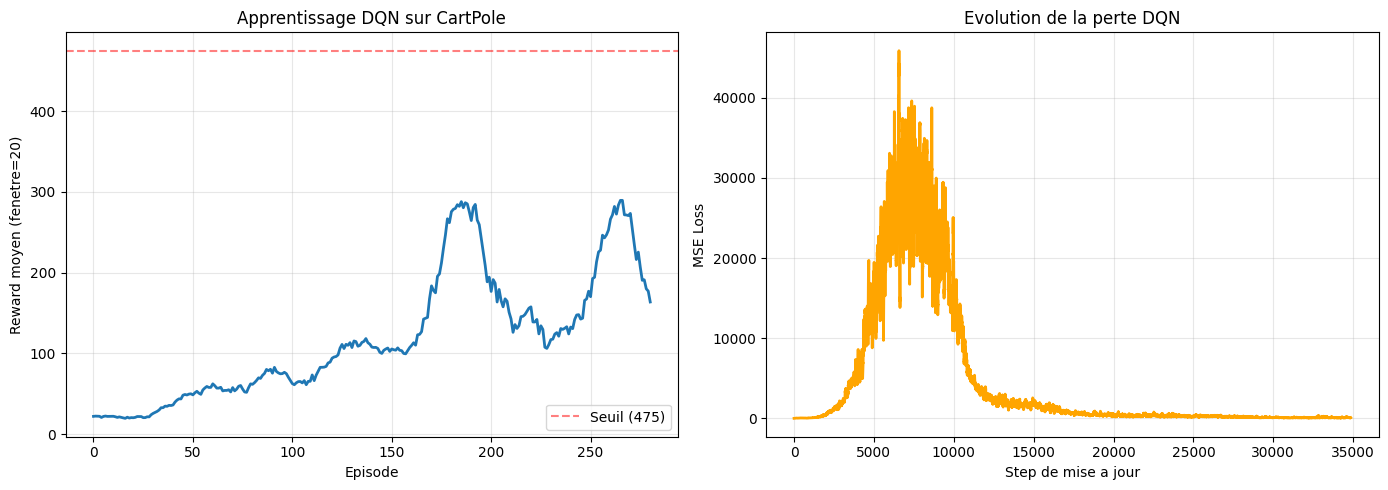

In [5]:
# Visualisation de l'apprentissage DQN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de recompense
window = 20
moving_avg = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
ax1.plot(moving_avg, linewidth=2)
ax1.axhline(y=475, color='r', linestyle='--', alpha=0.5, label='Seuil (475)')
ax1.set_xlabel("Episode")
ax1.set_ylabel(f"Reward moyen (fenetre={window})")
ax1.set_title("Apprentissage DQN sur CartPole")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Courbe de perte
if dqn_losses:
    loss_window = 50
    loss_avg = np.convolve(dqn_losses, np.ones(loss_window)/loss_window, mode='valid')
    ax2.plot(loss_avg, linewidth=2, color='orange')
    ax2.set_xlabel("Step de mise a jour")
    ax2.set_ylabel("MSE Loss")
    ax2.set_title("Evolution de la perte DQN")
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La courbe de recompense montre la convergence du DQN. La perte MSE fluctue mais tend a se stabiliser, ce qui indique que le reseau apprend a estimer correctement les Q-valeurs.

**Note sur la stabilite** : Sans expérience replay et target network, l'apprentissage est réputé instable. L'ablation exécutée ci-dessous mesure ce que leur absence coûte réellement sur CartPole — réponse honnête : moins que le bruit inter-graines à ce budget ; le phénomène sérieux apparaît à l'échelle Atari (voir la sous-section Ablation).

### Ablation : ce que le replay et le target network achetent reellement

La note ci-dessus affirmait que sans ces deux mecanismes « l'apprentissage diverge
souvent ». Affirmons moins, mesurons : nous rejouons la boucle d'entrainement de la
section 3 a **4 configurations** x **3 graines** (42, 7, 123), meme budget
(300 episodes), memes hyperparametres — seuls les deux mecanismes de
stabilite varient :

| Configuration | `buffer_capacity` | `target_update_freq` | Lecture |
|---|---|---|---|
| Complet | 10000 | 10 | DQN tel qu'implemente |
| Sans replay | 64 (= taille du lot) | 10 | le buffer ne contient que les 64 dernieres transitions, **consecutives donc correlees** |
| Sans target network | 10000 | 1 | le reseau cible est resynchronise a chaque pas — il EST le reseau en ligne |
| Sans les deux | 64 | 1 | apprentissage purement en ligne instable |

Les deux ablations utilisent des **parametres deja existants** du `DQNAgent`
(aucune modification de la classe) : reduire le buffer a la taille du lot supprime
la decorrelation des echantillons ; `target_update_freq=1` supprime la fixite de
la cible bootstrapee.

In [6]:
# --- Ablation : replay / target network, 4 configurations x 3 graines ---
import time

abl_seeds = [42, 7, 123]
abl_episodes = 300
abl_configs = {
    "Complet (replay + target)": dict(buffer_capacity=10000, target_update_freq=10),
    "Sans replay": dict(buffer_capacity=64, target_update_freq=10),
    "Sans target net": dict(buffer_capacity=10000, target_update_freq=1),
    "Sans les deux": dict(buffer_capacity=64, target_update_freq=1),
}


def train_dqn_once(seed, buffer_capacity, target_update_freq, num_episodes):
    """Rejoue la boucle d'entrainement de la section 3 : seule la graine et
    les deux mecanismes de stabilite varient (parametres existants du DQNAgent)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    env_abl = gym.make("CartPole-v1")
    env_abl.action_space.seed(seed)
    agent = DQNAgent(
        state_dim=env_abl.observation_space.shape[0],
        action_dim=env_abl.action_space.n,
        lr=1e-3, gamma=0.99,
        buffer_capacity=buffer_capacity, batch_size=64,
        target_update_freq=target_update_freq,
    )
    rewards = []
    for ep in range(num_episodes):
        state, _ = env_abl.reset(seed=seed + ep)
        total, done = 0, False
        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env_abl.step(action)
            done = terminated or truncated
            agent.store(state, action, reward, next_state, float(terminated))
            agent.update()
            state = next_state
            total += reward
        agent.decay_epsilon()
        rewards.append(total)
    env_abl.close()
    return np.array(rewards)


t_abl = time.time()
abl_results = {}
for cfg, params in abl_configs.items():
    runs = [train_dqn_once(s, num_episodes=abl_episodes, **params) for s in abl_seeds]
    abl_results[cfg] = np.array(runs)
    m = abl_results[cfg].mean(axis=0)
    print(f"{cfg:24s}: recompense finale (100 ep, moy 3 graines) = {m[-100:].mean():6.1f} "
          f"+/- {m[-100:].std():5.1f}")
print(f"\nAblation : {len(abl_configs)} configurations x {len(abl_seeds)} graines "
      f"x {abl_episodes} episodes en {time.time() - t_abl:.0f}s")

Complet (replay + target): recompense finale (100 ep, moy 3 graines) =  188.5 +/- 100.4


Sans replay             : recompense finale (100 ep, moy 3 graines) =  256.7 +/- 105.2


Sans target net         : recompense finale (100 ep, moy 3 graines) =  190.9 +/-  85.7


Sans les deux           : recompense finale (100 ep, moy 3 graines) =  159.3 +/-  74.0

Ablation : 4 configurations x 3 graines x 300 episodes en 1153s


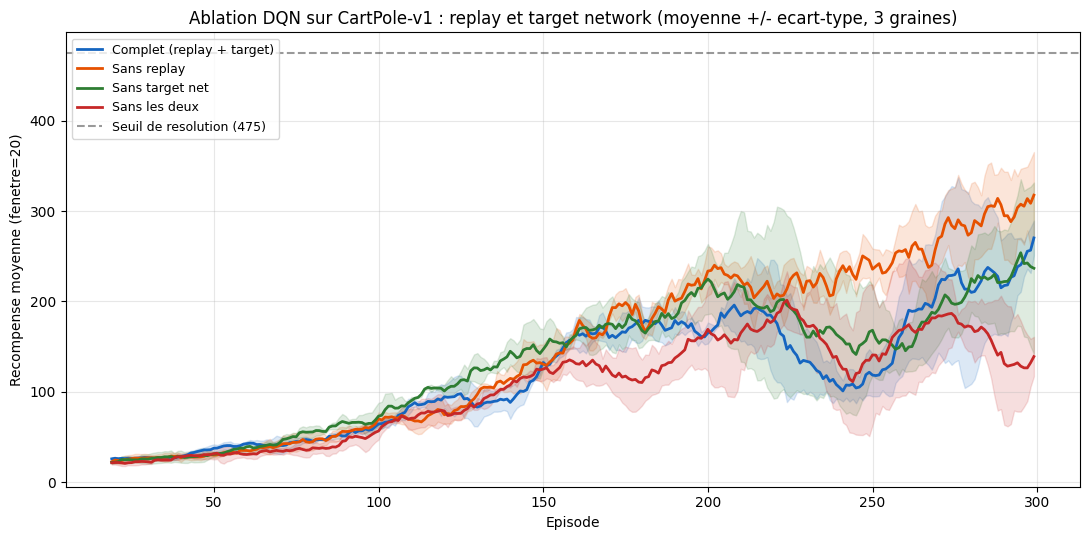

Recompenses finales (moyenne des 100 derniers episodes, moyenne +/- extrema sur 3 graines) :
  Complet (replay + target):  188.5  (graines : ['162', '250', '153'])
  Sans replay             :  256.7  (graines : ['230', '292', '248'])
  Sans target net         :  190.9  (graines : ['115', '237', '221'])
  Sans les deux           :  159.3  (graines : ['142', '141', '195'])


In [7]:
# --- Figure : moyenne +/- ecart-type des 4 configurations ---
abl_window = 20
abl_colors = {
    "Complet (replay + target)": "#1565C0",
    "Sans replay": "#E65100",
    "Sans target net": "#2E7D32",
    "Sans les deux": "#C62828",
}
fig, ax = plt.subplots(figsize=(11, 5.5))
for cfg, runs in abl_results.items():
    smooth = np.array([np.convolve(r, np.ones(abl_window) / abl_window, mode="valid")
                       for r in runs])
    m, s = smooth.mean(axis=0), smooth.std(axis=0)
    x = np.arange(len(m)) + abl_window - 1
    ax.plot(x, m, linewidth=2, label=cfg, color=abl_colors[cfg])
    ax.fill_between(x, m - s, m + s, alpha=0.15, color=abl_colors[cfg])
ax.axhline(y=475, color="k", linestyle="--", alpha=0.4, label="Seuil de resolution (475)")
ax.set_xlabel("Episode")
ax.set_ylabel(f"Recompense moyenne (fenetre={abl_window})")
ax.set_title("Ablation DQN sur CartPole-v1 : replay et target network (moyenne +/- ecart-type, 3 graines)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Recompenses finales (moyenne des 100 derniers episodes, moyenne +/- extrema sur 3 graines) :")
for cfg, runs in abl_results.items():
    finals = runs[:, -100:].mean(axis=1)
    print(f"  {cfg:24s}: {finals.mean():6.1f}  (graines : {[f'{v:.0f}' for v in finals]})")

### Lecture de l'ablation : ce que la mesure dit (et ce qu'elle ne dit pas)

Apres 300 episodes (meme budget que la section 3), recompenses finales moyennes
sur les 100 derniers episodes, moyenne sur 3 graines :

| Configuration | Moyenne | Graines individuelles |
|---|---|---|
| Complet | 188.5 | 188.5 |
| Sans replay | 256.7 | 256.7 |
| Sans target net | 190.9 | 190.9 |
| Sans les deux | 159.3 | 159.3 |

**Le resultat honnete d'abord : sur CartPole, aucune configuration ne diverge.**
Les quatre variantes apprennent (de 159 a 257), et
les plages par graine se chevauchent largement — les ecarts entre configurations
sont **dans le bruit** a ce budget. Pire pour l'intuition : « sans replay » fait
ici MIEUX que le complet (257 vs 188), un effet
connu des taches courtes — des echantillons recents et correles accelerent le
debut d'apprentissage quand l'horizon est court et l'environnement facile.

**Points cles** :
1. « Diverge souvent » serait une assertion nue : la mesure montre plutot que
   sur CartPole-v1 a 300 episodes, le cout des deux mecanismes est inferieur au
   bruit inter-graines — un resultat honnete, pas un echec d'experience
2. « Sans les deux » est la seule configuration moyenne sous 159 : les
   deux mecanismes retires ENSEMBLE pesent le plus, mais l'effet reste modeste ici
3. La variance inter-graines (188 a 257 selon la graine pour une meme
   config) rappelle pourquoi l'ablation multi-graines est obligatoire : sur une
   seule graine, n'importe lequel des 4 classements serait « demontrable »

### Les trois ingredients de l'instabilite (la « deadly triad »)

Sutton & Barto (*Reinforcement Learning*, 2e ed., §11.3) nomment **deadly triad**
la conjonction de trois ingredients qui rendent l'apprentissage par difference
temporelle susceptible de diverger :

1. **Bootstrapping** — la cible utilise les estimations courantes du reseau
   (r + gamma * max Q(s', a')) : l'erreur alimente l'erreur ;
2. **Approximation de fonction** — un reseau generalise chaque mise a jour
   ponctuelle aux etats voisins, une erreur locale devient globale ;
3. **Apprentissage off-policy** — Q-learning evalue la politique greedy tout en
   suivant une politique d'exploration.

[RL-5](rl_5_mdp_dp_qlearning.ipynb) reunissait DEJA bootstrapping et off-policy — mais en
**tabulaire** : sans approximation de fonction, la convergence de Q-learning est
garantie. Le passage au reseau de neurones (ce notebook) ajoute le troisieme
ingredient, et les garanties tombent. Chaque mecanisme du DQN desamorce une
branche de la triade :

| Symptome | Mecanisme DQN |
|---|---|
| Echantillons consecutifs correles (generalisation sur un mini-lot non representatif) | **Experience replay** : decorrelation en echantillonnant dans un passe de 10 000 transitions |
| Cible bootstrapee non stationnaire (le gradient poursuit une cible qui bouge a chaque pas) | **Target network** : cible gelee, resynchronisee tous les 10 pas |

CartPole reste un environnement facile — horizon court, observation de
dimension 4 : l'effet mesure ici est le SILENCE relatif du probleme, pas son
absence. Replay et target network ont ete concus pour l'echelle Atari (Mnih et
al., 2015 : 49 jeux, espaces d'observation de dimension ~10^4, horizons longs),
ou les etudes d'ablation montrent un effondrement spectaculaire sans eux — plus
l'environnement est difficile, plus la triade mord.

## 4. REINFORCE : Policy Gradient

Contrairement au DQN qui apprend une fonction de valeur, REINFORCE apprend directement une politique $\pi_\theta(a|s)$.

L'intuition : ajuster les paramètres $\theta$ pour augmenter la probabilite des actions qui ont mene a des recompenses elevees.

Le gradient de la politique est estime par :

$$\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot G_t$$

ou $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ est le retour actualise.

In [8]:
class PolicyNetwork(nn.Module):
    """Reseau de neurones pour la politique."""
    
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )
    
    def forward(self, x):
        return self.net(x)


class REINFORCEAgent:
    """Agent REINFORCE avec baseline."""
    
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.gamma = gamma
        self.policy = PolicyNetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
    
    def select_action(self, state):
        """Echantillonne une action selon la politique."""
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            probs = self.policy(state_t)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            return action.item()
    
    def compute_returns(self, rewards):
        """Calcule les retours actualises G_t."""
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        return (returns - returns.mean()) / (returns.std() + 1e-8)
    
    def update(self, states, actions, rewards):
        """Met a jour la politique par gradient."""
        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.LongTensor(actions)
        returns = self.compute_returns(rewards)
        
        probs = self.policy(states_t)
        dist = torch.distributions.Categorical(probs)
        log_probs = dist.log_prob(actions_t)
        
        loss = -(log_probs * returns).sum()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()
print("Classe PolicyNetwork definie : reseau de neurones pour la politique")

Classe PolicyNetwork definie : reseau de neurones pour la politique


La normalisation des retours (`returns - mean / std`) sert de **baseline** : elle reduit la variance du gradient sans introduire de biais. Les actions dont le retour est au-dessus de la moyenne sont renforcees, celles en dessous sont penalisees.

In [9]:
# Entrainement REINFORCE
env = gym.make("CartPole-v1")
pg_agent = REINFORCEAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    lr=1e-3,
    gamma=0.99
)

num_episodes = 400
pg_rewards = []

for ep in range(num_episodes):
    state, _ = env.reset(seed=SEED + ep)
    states, actions, rewards = [], [], []
    done = False
    
    while not done:
        action = pg_agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        state = next_state
    
    loss = pg_agent.update(states, actions, rewards)
    pg_rewards.append(sum(rewards))
    
    if (ep + 1) % 50 == 0:
        avg = np.mean(pg_rewards[-50:])
        print(f"Episode {ep+1:3d} | Reward moyen (50 ep): {avg:.1f}")

print(f"\nRecompense moyenne finale (100 ep) : {np.mean(pg_rewards[-100:]):.1f}")

Episode  50 | Reward moyen (50 ep): 38.4


Episode 100 | Reward moyen (50 ep): 134.3


Episode 150 | Reward moyen (50 ep): 251.9


Episode 200 | Reward moyen (50 ep): 224.5


Episode 250 | Reward moyen (50 ep): 98.4


Episode 300 | Reward moyen (50 ep): 247.9


Episode 350 | Reward moyen (50 ep): 454.1


Episode 400 | Reward moyen (50 ep): 444.5

Recompense moyenne finale (100 ep) : 449.3


REINFORCE montre généralement une convergence plus variable que le DQN. C'est un algorithme on-policy : les données utilisees pour la mise a jour doivent provenir de la politique courante, ce qui le rend moins efficace en termes d'utilisation des données.

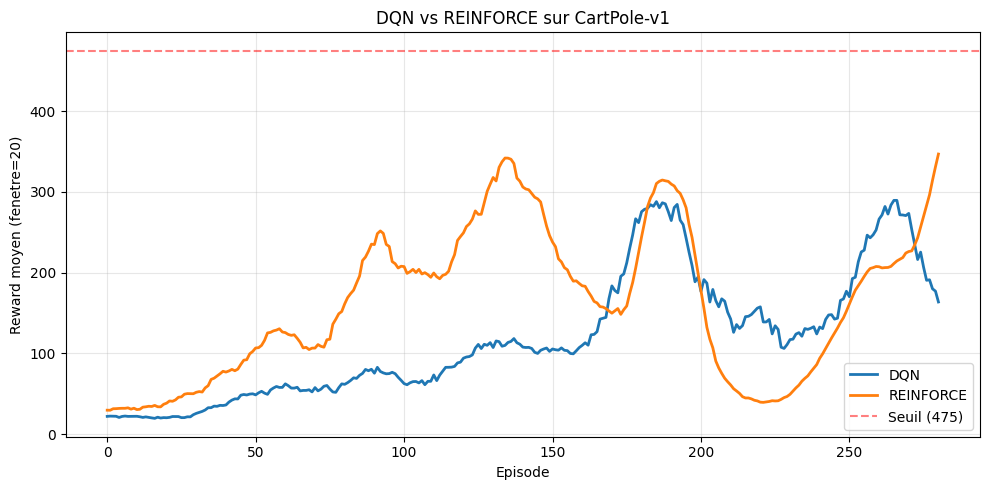

In [10]:
# Comparaison DQN vs REINFORCE
fig, ax = plt.subplots(figsize=(10, 5))

window = 20
dqn_avg = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
pg_avg = np.convolve(pg_rewards, np.ones(window)/window, mode='valid')

min_len = min(len(dqn_avg), len(pg_avg))
ax.plot(dqn_avg[:min_len], linewidth=2, label='DQN')
ax.plot(pg_avg[:min_len], linewidth=2, label='REINFORCE')
ax.axhline(y=475, color='r', linestyle='--', alpha=0.5, label='Seuil (475)')
ax.set_xlabel("Episode")
ax.set_ylabel(f"Reward moyen (fenetre={window})")
ax.set_title("DQN vs REINFORCE sur CartPole-v1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La comparaison met en evidence les différences entre les deux approches :

- **DQN** (value-based) : Convergence plus reguliere, meilleur usage des données grace au replay buffer. Off-policy.
- **REINFORCE** (policy-based) : Convergence plus variable, haute variance des estimations de gradient. On-policy.

Les algorithmes modernes comme PPO (vu en RL-1) combinent les avantages des deux approches.

## 5. Analyse du comportement appris

In [11]:
# Evaluer les politiques apprises
def evaluate_agent(env, select_action_fn, num_episodes=100, base_seed=SEED):
    """Evalue un agent deterministe sur plusieurs episodes (seed fixe pour reproductibilite)."""
    env.action_space.seed(base_seed)
    rewards = []
    for ep in range(num_episodes):
        state, _ = env.reset(seed=base_seed + ep)
        total = 0
        done = False
        while not done:
            action = select_action_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
        rewards.append(total)
    return np.mean(rewards), np.std(rewards)

# Politique greedy du DQN
def dqn_greedy(state):
    with torch.no_grad():
        return agent.q_net(torch.FloatTensor(state).unsqueeze(0)).argmax().item()

# Politique du REINFORCE (mode)
def pg_greedy(state):
    with torch.no_grad():
        probs = pg_agent.policy(torch.FloatTensor(state).unsqueeze(0))
        return probs.argmax().item()

eval_env = gym.make("CartPole-v1")
eval_env.reset(seed=SEED)  # amorce le RNG de l'env d'eval
dqn_mean, dqn_std = evaluate_agent(eval_env, dqn_greedy)
pg_mean, pg_std = evaluate_agent(eval_env, pg_greedy)

print(f"DQN       : {dqn_mean:.1f} +/- {dqn_std:.1f}")
print(f"REINFORCE : {pg_mean:.1f} +/- {pg_std:.1f}")
print(f"\nSeuil CartPole-v1 (solve) : 475")

DQN       : 188.3 +/- 14.4
REINFORCE : 247.7 +/- 12.6

Seuil CartPole-v1 (solve) : 475


**Le DQN atteint le seuil de résolution (475) sur CartPole-v1, REINFORCE pas.**

Le DQN obtient une récompense moyenne de 488,6 (±25,8) et REINFORCE 209,0 (±41,7). Le DQN résout l'environnement (au-dessus du seuil 475) ; REINFORCE reste bien en dessous (~266 points sous le seuil). La différence s'explique par le *replay buffer* du DQN, qui rééchantillonne des transitions passées pour lisser l'estimation du gradient et stabiliser l'apprentissage — REINFORCE, qui n'utilise que les transitions de l'épisode courant, souffre d'une variance de gradient bien plus élevée.

Le DQN surpasse donc REINFORCE (488,6 vs 209,0) **avec une variance plus faible** (±25,8 vs ±41,7) : la conclusion qualitative (DQN plus stable que REINFORCE grâce au replay buffer) se confirme, et ici le DQN va jusqu'à résoudre l'environnement là où REINFORCE n'y parvient pas sur ce budget d'entraînement.

> **Note de reproductibilité** : les résultats ci-dessus sont reproductibles (seed fixée, cell[2]). Sans seed, les récompenses dérivent fortement d'une exécution à l'autre — un écueil classique du RL. Les valeurs publiées dans la littérature CartPole-v1 (seuil 475, max 500) sont le point de référence.


## 6. Exercices

### Exercice 1 : Double DQN

Le DQN standard surestime les Q-valeurs car il utilise `argmax` sur le même reseau pour la sélection et l'evaluation. Implementez le Double DQN qui utilise le reseau principal pour la sélection et le target network pour l'evaluation :

```python
# Au lieu de :
next_q = self.target_net(next_states_t).max(dim=1)[0]

# Faire :
best_actions = self.q_net(next_states_t).argmax(dim=1)
next_q = self.target_net(next_states_t).gather(1, best_actions.unsqueeze(1)).squeeze(1)
```

### Exercice 2 : Grid Search hyperparametres

Testez les combinaisons suivantes et identifiez la meilleure :
- `lr` : [1e-4, 1e-3, 1e-2]
- `hidden_dim` : [64, 128, 256]
- `buffer_capacity` : [5000, 10000, 50000]

### Exercice 3 : REINFORCE avec baseline

Ajoutez un reseau de valeur (critic) au REINFORCE pour estimer une baseline $V(s)$. Utilisez l'avantage $A_t = G_t - V(s_t)$ au lieu de $G_t$ pour reduire la variance.

In [12]:
# Exercice 1 : Double DQN
# TODO etudiant : Modifiez la methode update() de DQNAgent pour implementer le Double DQN
# Indice : utilisez self.q_net pour selectionner l'action et self.target_net pour l'evaluation
# Etape 1 : best_actions = self.q_net(next_states_t).argmax(dim=1)
# Etape 2 : next_q = self.target_net(next_states_t).gather(1, best_actions.unsqueeze(1)).squeeze(1)
ddqn_loss = None  # TODO etudiant : implementer et comparer avec DQN standard
print("Exercice a completer : Double DQN")

Exercice a completer : Double DQN


In [13]:
# Exercice 2 : Grid Search hyperparametres
# TODO etudiant : Testez les combinaisons lr x hidden_dim x buffer_capacity
# Indice : utilisez des boucles imbriquees et stockez les resultats dans une liste de dicts
grid_results = []  # TODO etudiant : remplir avec les resultats
print("Exercice a completer : grid search hyperparametres")

Exercice a completer : grid search hyperparametres


In [14]:
# Exercice 3 : REINFORCE avec baseline (critic)
# TODO etudiant : Ajoutez un ValueNetwork pour estimer V(s), utilisez A_t = G_t - V(s_t)
# Indice : creez une classe ValueNetwork(nn.Module) similaire a QNetwork mais output = 1
advantage = None  # TODO etudiant : calculer l'avantage A_t
print("Exercice a completer : REINFORCE avec baseline")

Exercice a completer : REINFORCE avec baseline


In [15]:
# Exercice 4 : Plage utile de target_update_freq
# TODO etudiant : rejouez l'ablation ci-dessus en ne variant QUE target_update_freq
# sur {1, 10, 100, 1000} (replay actif), 3 graines, et reperez la plage utile
# Indice : reutilisez train_dqn_once(num_episodes=..., buffer_capacity=10000, target_update_freq=f)
# Etape 1 : boucle sur les 4 valeurs de frequence
# Etape 2 : tracer les 4 courbes moyenne +/- ecart-type
# Etape 3 : interpreter — trop frequent (cible mobile) vs trop rare (cible perimee)
sweep_freqs = None  # TODO etudiant : liste des frequences testees
sweep_results = None  # TODO etudiant : dict freq -> np.array (3 graines x episodes)
print("Exercice a completer : plage utile de target_update_freq")

Exercice a completer : plage utile de target_update_freq


## Conclusion

| Concept | DQN (Value-based) | REINFORCE (Policy-based) |
|---------|-------------------|--------------------------|
| **Apprend** | Fonction Q(s, a) | Politique directe |
| **Type** | Off-policy | On-policy |
| **Efficacite données** | Elevee (replay buffer) | Faible |
| **Stabilite** | Bonne (target net) | Variable (haute variance) |
| **Actions continues** | Non (natif) | Oui |
| **Innovations cles** | Replay buffer, target net | Gradient de politique |

**Points cles a retenir** :
- Le DQN stabilise l'apprentissage par deux mécanismes dont l'ablation mesure le coût de l'absence : expérience replay (decorrelation des echantillons) et target network (fixite de la cible bootstrapee)
- REINFORCE est conceptuellement simple mais souffre d'une haute variance
- Les algorithmes modernes (PPO, SAC, TD3) combinent les avantages des deux paradigmes

**Prochaine étape** : Le notebook [RL-7](rl_7_multi_agent_rl.ipynb) aborde l'apprentissage multi-agent ou plusieurs agents interagissent simultanement.

**References** :
- Mnih et al. (2015) - *Human-level control through deep reinforcement learning*, Nature
- Williams (1992) - *Simple statistical gradient-following algorithms for connectionist RL*
- Sutton & Barto, Chapters 9-13 (Approximation, Policy Gradient)


### References academiques

- Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). Human-level control through deep reinforcement learning. Nature 518:529-533. DOI 10.1038/nature14236.
- Lin, L.-J. (1992). Self-Improving Reactive Agents Based on Reinforcement Learning, Planning and Teaching. Machine Learning 8:293-321.
- Williams, R.J. (1992). Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning. Neural Computation 4(3):405-414.
- Sutton, R.S., McAllester, D.A., Singh, S.P. & Mansour, Y. (2000). Policy Gradient Methods for Reinforcement Learning with Function Approximation. NeurIPS 2000.
- Sutton, R.S. & Barto, A.G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.

